In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk joblib streamlit jupyter

     ---------------------------------------- 80.9/80.9 kB 1.1 MB/s eta 0:00:00
  Attempting uninstall: anyio
    Found existing installation: anyio 4.9.0
    Uninstalling anyio-4.9.0:
      Successfully uninstalled anyio-4.9.0
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import nltk
import joblib

print("Python environment is ready!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

C:\Users\Hp\anaconda3\anaconda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Python environment is ready!
Pandas: 2.2.2
NumPy: 1.26.4
Scikit-learn: 1.3.2


In [6]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_PATH = r"C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\data\SMSSpamCollection"

print("Dataset path:")
print(DATA_PATH)


Dataset path:
C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\data\SMSSpamCollection


In [7]:
df = pd.read_csv(
    DATA_PATH,
    sep="\t",
    header=None,
    names=["label", "message"]
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (5572, 2)


In [8]:
df.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5572
Number of columns: 2


In [10]:
print(df.columns.tolist())

['label', 'message']


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [12]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 403


In [14]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (5169, 2)


In [15]:
print(df["label"].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


In [16]:
label_percentage = df["label"].value_counts(normalize=True) * 100

print(label_percentage.round(2))

label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


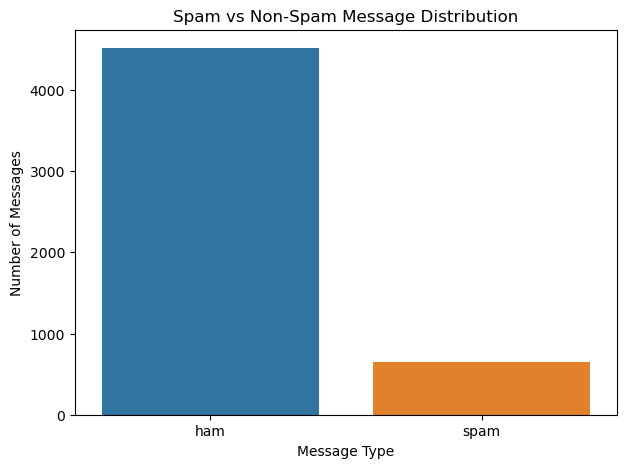

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Spam vs Non-Spam Message Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [19]:
spam_messages = df[df["label"] == "spam"]

spam_messages.head(10)

,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
12,spam,URGENT! You have won a 1 week FREE membership ...
15,spam,"XXXMobileMovieClub: To use your credit, click ..."
19,spam,England v Macedonia - dont miss the goals/team...
34,spam,Thanks for your subscription to Ringtone UK yo...
42,spam,07732584351 - Rodger Burns - MSG = We tried to...


In [20]:
ham_messages = df[df["label"] == "ham"]

ham_messages.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
10,ham,I'm gonna be home soon and i don't want to tal...
13,ham,I've been searching for the right words to tha...
14,ham,I HAVE A DATE ON SUNDAY WITH WILL!!
16,ham,Oh k...i'm watching here:)


In [21]:
df["message_length"] = df["message"].str.len()

df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


C:\Users\Hp\anaconda3\anaconda\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hp\anaconda3\anaconda\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Hp\anaconda3\anaconda\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Hp\anaconda3\anaconda\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: 

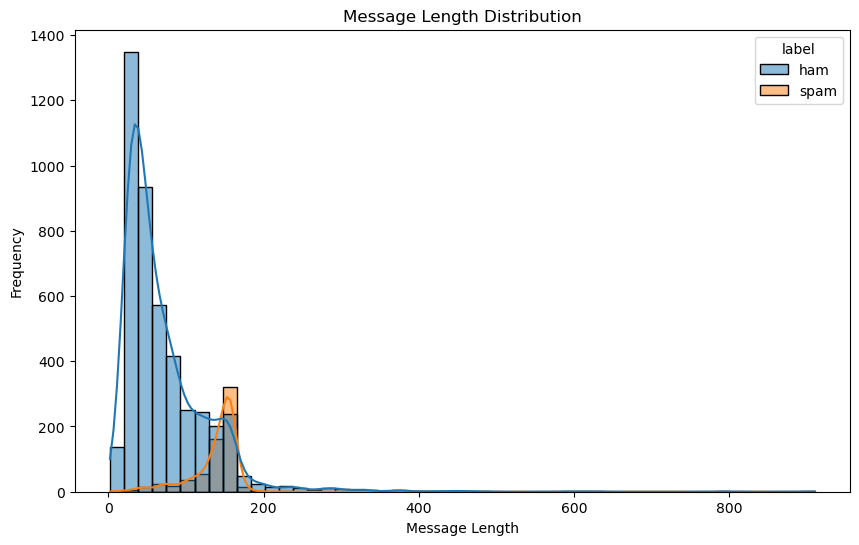

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

In [23]:
average_length = df.groupby("label")["message_length"].mean()

print("Average message length:")
print(average_length)

Average message length:
label
ham      70.905890
spam    137.704441
Name: message_length, dtype: float64


In [24]:
from collections import Counter
import re

def get_word_frequency(messages):
    words = []

    for message in messages:
        message = message.lower()
        message = re.sub(r"[^a-zA-Z\s]", " ", message)
        words.extend(message.split())

    return Counter(words)

In [25]:
spam_word_frequency = get_word_frequency(
    df[df["label"] == "spam"]["message"]
)

spam_word_frequency.most_common(20)

[('to', 599),
 ('a', 347),
 ('call', 322),
 ('you', 270),
 ('your', 242),
 ('free', 197),
 ('for', 185),
 ('the', 183),
 ('now', 168),
 ('or', 160),
 ('p', 158),
 ('u', 157),
 ('is', 144),
 ('txt', 141),
 ('from', 123),
 ('on', 122),
 ('ur', 119),
 ('stop', 116),
 ('have', 115),
 ('mobile', 111)]

In [26]:
df = df.drop(columns=["message_length"])

print(df.columns.tolist())

['label', 'message']


In [27]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nData types:")
print(df.dtypes)

Final dataset shape: (5169, 2)

Missing values:
label      0
message    0
dtype: int64

Duplicate rows:
0

Class distribution:
label
ham     4516
spam     653
Name: count, dtype: int64

Data types:
label      object
message    object
dtype: object


In [30]:
CLEAN_DATA_PATH = BASE_DIR / r"C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\data" / "spam_cleaned.csv"

df.to_csv(
    CLEAN_DATA_PATH,
    index=False
)

print("Cleaned dataset saved to:")
print(CLEAN_DATA_PATH)

Cleaned dataset saved to:
C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\data\spam_cleaned.csv


In [31]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
CLEAN_DATA_PATH = BASE_DIR / r"C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\data" / "spam_cleaned.csv"

df = pd.read_csv(CLEAN_DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (5169, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [32]:
for i, message in enumerate(df["message"].head(10), start=1):
    print(f"\nMessage {i}:")
    print(message)


Message 1:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Message 2:
Ok lar... Joking wif u oni...

Message 3:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Message 4:
U dun say so early hor... U c already then say...

Message 5:
Nah I don't think he goes to usf, he lives around here though

Message 6:
FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv

Message 7:
Even my brother is not like to speak with me. They treat me like aids patent.

Message 8:
As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune

Message 9:
WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To 

In [41]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...


True

In [46]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [47]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

print("Number of English stopwords:", len(stop_words))

Number of English stopwords: 198


In [48]:
def clean_text(text):
    """
    Clean an email/message for NLP classification.
    """

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [49]:
test_message = """
Congratulations! You have WON a FREE prize.
Visit https://example.com now!
"""

print("Original:")
print(test_message)

print("\nCleaned:")
print(clean_text(test_message))

Original:

Congratulations! You have WON a FREE prize.
Visit https://example.com now!


Cleaned:
congratulation free prize visit


In [50]:
sample = df["message"].iloc[2]

print("Original message:")
print(sample)

print("\nCleaned message:")
print(clean_text(sample))

Original message:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Cleaned message:
free entry 2 wkly comp win fa cup final tkts 21st may 2005 text fa 87121 receive entry questionstd txt ratetcs apply 08452810075over18s


In [51]:
df["clean_message"] = df["message"].apply(clean_text)

df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [52]:
comparison = df[["message", "clean_message"]].head(10)

comparison

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling 3 week word back id like f...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile 11 month u r entitled update latest col...


In [53]:
empty_messages = df["clean_message"].str.strip().eq("").sum()

print("Empty cleaned messages:", empty_messages)

Empty cleaned messages: 5


In [55]:
df = df[df["clean_message"].str.strip() != ""].copy()

print("Shape after removing empty messages:", df.shape)

Shape after removing empty messages: (5164, 3)


In [56]:
df["original_length"] = df["message"].str.len()
df["clean_length"] = df["clean_message"].str.len()

df[["original_length", "clean_length"]].describe()

,original_length,clean_length
count,5164.000000,5164.000000
mean,79.411503,52.231022
std,58.425663,40.213105
min,2.000000,1.000000
25%,36.000000,22.000000
50%,61.000000,38.000000
75%,119.000000,75.000000
max,910.000000,513.000000


C:\Users\Hp\anaconda3\anaconda\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


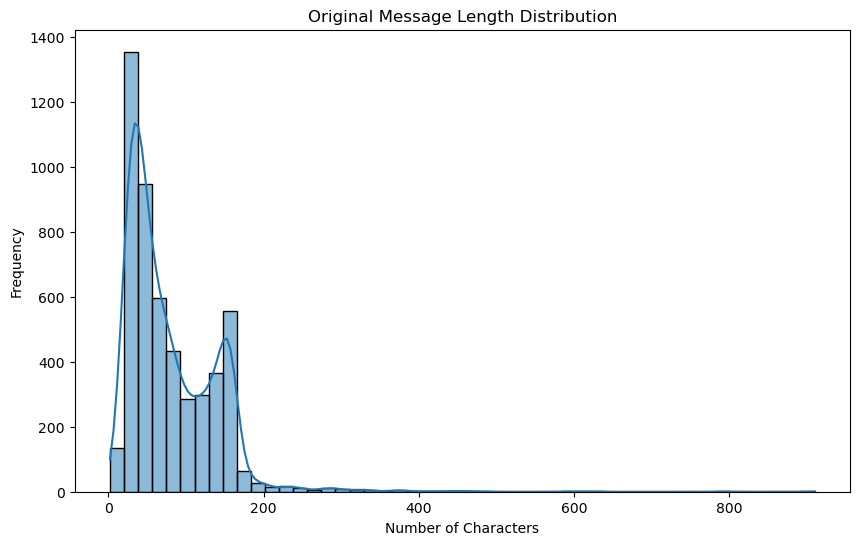

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    df["original_length"],
    bins=50,
    kde=True
)

plt.title("Original Message Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

C:\Users\Hp\anaconda3\anaconda\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


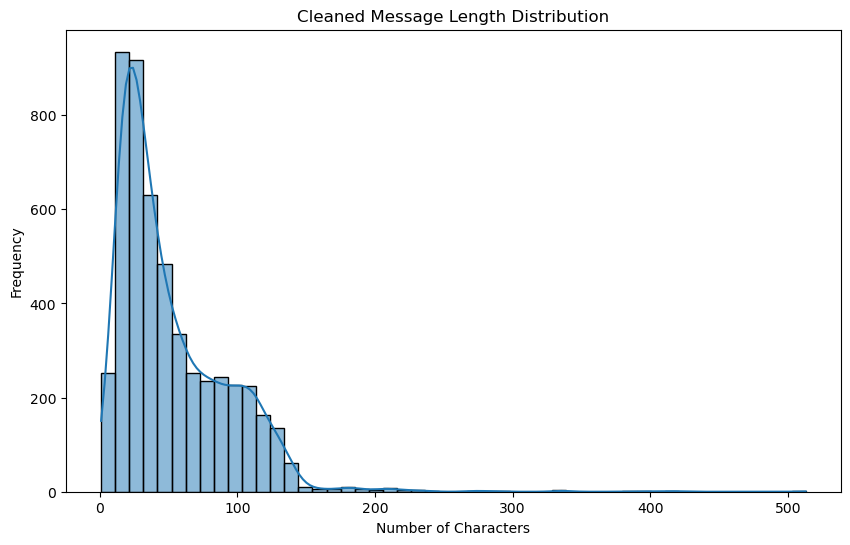

In [58]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["clean_length"],
    bins=50,
    kde=True
)

plt.title("Cleaned Message Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

In [59]:
df[df["label"] == "spam"][["message", "clean_message"]].head(10)

,message,clean_message
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling 3 week word back id like f...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile 11 month u r entitled update latest col...
11,"SIX chances to win CASH! From 100 to 20,000 po...",six chance win cash 100 20000 pound txt csh11 ...
12,URGENT! You have won a 1 week FREE membership ...,urgent 1 week free membership £100000 prize ja...
15,"XXXMobileMovieClub: To use your credit, click ...",xxxmobilemovieclub use credit click wap link n...
19,England v Macedonia - dont miss the goals/team...,england v macedonia dont miss goalsteam news t...
34,Thanks for your subscription to Ringtone UK yo...,thanks subscription ringtone uk mobile charged...
42,07732584351 - Rodger Burns - MSG = We tried to...,07732584351 rodger burn msg tried call reply s...


In [60]:
df[df["label"] == "ham"][["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
10,I'm gonna be home soon and i don't want to tal...,im gonna home soon dont want talk stuff anymor...
13,I've been searching for the right words to tha...,ive searching right word thank breather promis...
14,I HAVE A DATE ON SUNDAY WITH WILL!!,date sunday
16,Oh k...i'm watching here:),oh kim watching


In [61]:
from collections import Counter

def get_clean_word_frequency(messages):
    words = []

    for message in messages:
        words.extend(message.split())

    return Counter(words)

In [62]:
spam_words = get_clean_word_frequency(
    df.loc[df["label"] == "spam", "clean_message"]
)

spam_words.most_common(20)

[('call', 314),
 ('free', 189),
 ('2', 155),
 ('u', 130),
 ('txt', 126),
 ('text', 120),
 ('ur', 119),
 ('mobile', 114),
 ('stop', 105),
 ('claim', 98),
 ('4', 97),
 ('reply', 94),
 ('prize', 82),
 ('get', 69),
 ('new', 64),
 ('service', 64),
 ('tone', 62),
 ('send', 58),
 ('urgent', 58),
 ('nokia', 54)]

In [63]:
ham_words = get_clean_word_frequency(
    df.loc[df["label"] == "ham", "clean_message"]
)

ham_words.most_common(20)

[('u', 942),
 ('im', 436),
 ('get', 306),
 ('2', 292),
 ('go', 268),
 ('ltgt', 254),
 ('dont', 248),
 ('ok', 247),
 ('know', 229),
 ('got', 226),
 ('come', 226),
 ('like', 224),
 ('good', 208),
 ('ill', 207),
 ('time', 205),
 ('ur', 202),
 ('call', 195),
 ('day', 193),
 ('want', 180),
 ('love', 179)]

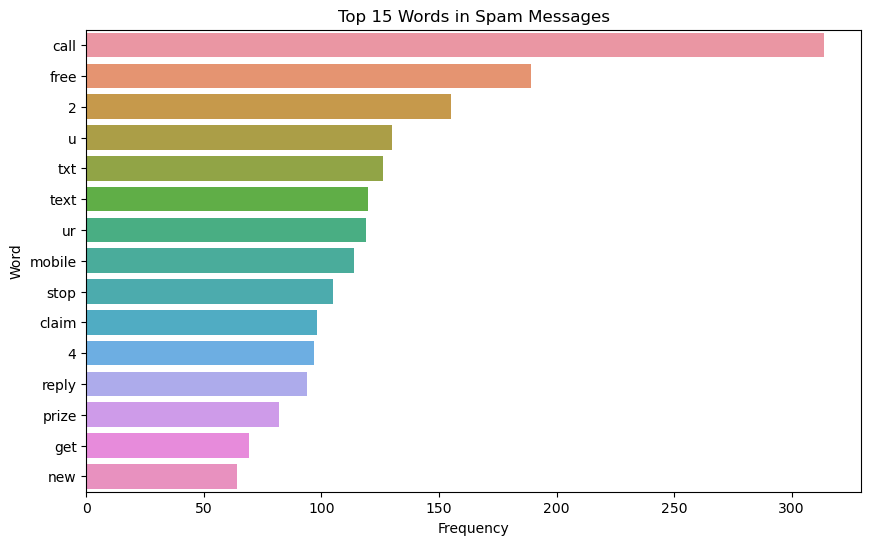

In [64]:
spam_top_words = pd.DataFrame(
    spam_words.most_common(15),
    columns=["word", "count"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=spam_top_words,
    x="count",
    y="word"
)

plt.title("Top 15 Words in Spam Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

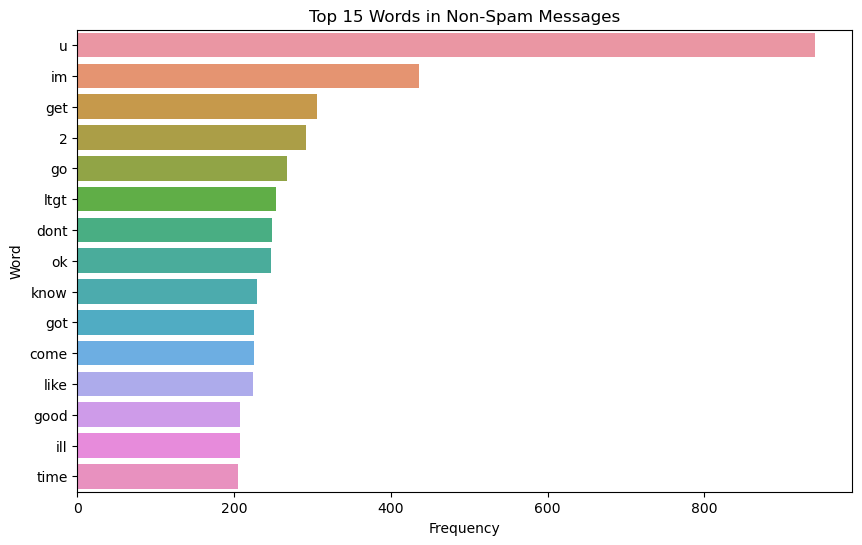

In [66]:
ham_top_words = pd.DataFrame(
    ham_words.most_common(15),
    columns=["word", "count"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=ham_top_words,
    x="count",
    y="word"
)

plt.title("Top 15 Words in Non-Spam Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

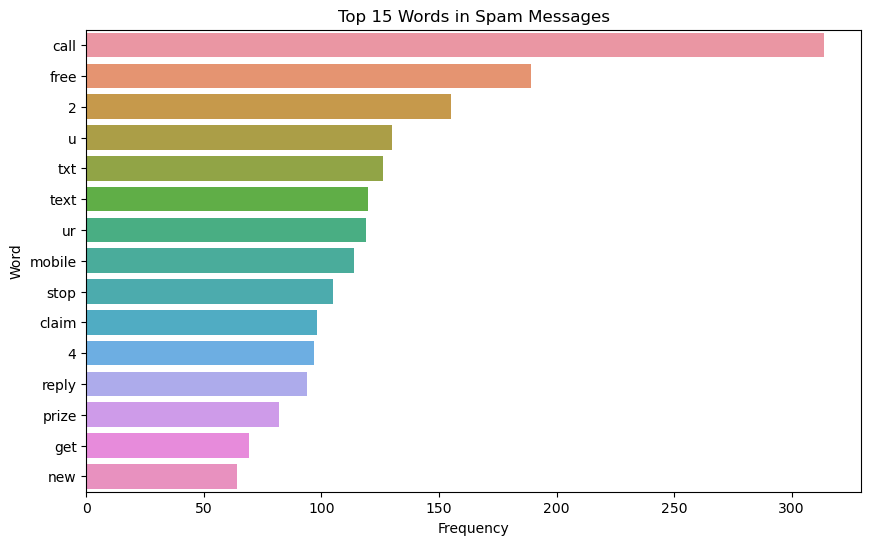

In [68]:
spam_top_words = pd.DataFrame(
    spam_words.most_common(15),
    columns=["word", "count"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=spam_top_words,
    x="count",
    y="word"
)

plt.title("Top 15 Words in Spam Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [69]:
df = df.drop(
    columns=["original_length", "clean_length"]
)

df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [70]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (5164, 3)

Columns:
['label', 'message', 'clean_message']

Missing values:
label            0
message          0
clean_message    0
dtype: int64

Duplicate rows:
0


In [71]:
PROCESSED_DATA_PATH = BASE_DIR / r"C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\data" / "spam_preprocessed.csv"

df.to_csv(
    PROCESSED_DATA_PATH,
    index=False
)

print("Preprocessed dataset saved successfully.")
print(PROCESSED_DATA_PATH)

Preprocessed dataset saved successfully.
C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\data\spam_preprocessed.csv


In [72]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent

PROCESSED_DATA_PATH = (
    BASE_DIR / r"C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\data" / "spam_preprocessed.csv"
)

df = pd.read_csv(PROCESSED_DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (5164, 3)


,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [73]:
print(df.columns.tolist())

['label', 'message', 'clean_message']


In [74]:
df["target"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df[["label", "target"]].head(10)

,label,target
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0
5,spam,1
6,ham,0
7,ham,0
8,spam,1
9,spam,1


In [75]:
print(df["target"].value_counts())

target
0    4511
1     653
Name: count, dtype: int64


In [76]:
print(df.groupby("label")["target"].unique())

label
ham     [0]
spam    [1]
Name: target, dtype: object


In [77]:
X = df["clean_message"]
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5164,)
y shape: (5164,)


In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4131
Testing samples: 1033


In [79]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training class distribution:
target
0    0.873638
1    0.126362
Name: proportion, dtype: float64

Testing class distribution:
target
0    0.873185
1    0.126815
Name: proportion, dtype: float64


In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [81]:
tfidf = TfidfVectorizer(
    lowercase=True,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print(tfidf)

TfidfVectorizer(max_df=0.95, max_features=5000, min_df=2, ngram_range=(1, 2),
                sublinear_tf=True)


In [82]:
ngram_range=(1, 2)

In [83]:
X_train_tfidf = tfidf.fit_transform(X_train)

print("X_train TF-IDF shape:", X_train_tfidf.shape)

X_train TF-IDF shape: (4131, 5000)


In [84]:
tfidf.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 36683 stored elements and shape (4131, 5000)>

In [85]:
X_test_tfidf = tfidf.transform(X_test)

print("X_test TF-IDF shape:", X_test_tfidf.shape)

X_test TF-IDF shape: (1033, 5000)


In [87]:
print("X_train:", X_train_tfidf.shape)
print("X_test :", X_test_tfidf.shape)

X_train: (4131, 5000)
X_test : (1033, 5000)


In [88]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 50 features:")
print(feature_names[:50])

Number of features: 5000

First 50 features:
['008704050406' '008704050406 sp' '020603' '020603 2nd' '020903'
 '020903 2nd' '050703' '050703 tcsbcm4235wc1n3xx' '0578' '071104'
 '0776xxxxxxx' '0776xxxxxxx uve' '07xxxxxxxxx' '07xxxxxxxxx 2000' '0800'
 '0800 542' '08000776320' '08000776320 reply' '08000839402'
 '08000839402 2stoptxt' '08000930705' '08000930705 del'
 '08000930705 delivery' '08000938767' '08000938767 update' '08001950382'
 '08001950382 call2optout674' '08002888812' '08002888812 reply' '0845'
 '0870' '0870 national' '08700621170150p' '08700621170150p per'
 '08707509020' '08707509020 20p' '08708034412' '08712300220'
 '08712300220 quoting' '08712317606' '08712405020' '08712405022'
 '08712405022 1x150pwk' '08712460324' '08712460324 10pmin'
 '08712460324 nat' '08715705022' '08715705022 1x150pwk' '08717898035'
 '08717898035 300']


In [89]:
sample_index = 0

sample_text = X_train.iloc[sample_index]
sample_vector = X_train_tfidf[sample_index]

print("Original cleaned message:")
print(sample_text)

print("\nNumber of non-zero TF-IDF features:")
print(sample_vector.nnz)

Original cleaned message:
sorry battery died come im getting gram wheres place

Number of non-zero TF-IDF features:
12


In [90]:
feature_values = sample_vector.toarray().flatten()

non_zero_indices = feature_values.nonzero()[0]

sample_features = pd.DataFrame({
    "feature": feature_names[non_zero_indices],
    "tfidf": feature_values[non_zero_indices]
})

sample_features.sort_values(
    "tfidf",
    ascending=False
).head(20)

,feature,tfidf
1,battery died,0.357107
10,sorry battery,0.357107
5,gram,0.344621
3,died,0.327023
0,battery,0.320332
7,im getting,0.320332
11,wheres,0.314537
4,getting,0.242567
8,place,0.237685
9,sorry,0.207142


In [91]:
print(type(X_train_tfidf))
print(type(X_test_tfidf))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>


In [92]:
total_values = (
    X_train_tfidf.shape[0] *
    X_train_tfidf.shape[1]
)

non_zero_values = X_train_tfidf.nnz

sparsity = 1 - (non_zero_values / total_values)

print(f"Sparsity: {sparsity:.4%}")

Sparsity: 99.8224%


In [93]:
split_summary = pd.DataFrame({
    "Train": y_train.value_counts(),
    "Test": y_test.value_counts()
})

split_summary.index = ["Ham", "Spam"]

split_summary

,Train,Test
Ham,3609,902
Spam,522,131


In [94]:
print("=" * 50)
print("PHASE 4 VALIDATION")
print("=" * 50)

print("\nOriginal dataset:", len(df))
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape :", X_test_tfidf.shape)

print("\nNumber of TF-IDF features:", len(feature_names))

print("\nSpam in training:", y_train.sum())
print("Spam in testing :", y_test.sum())

print("\nPhase 4 completed successfully.")

PHASE 4 VALIDATION

Original dataset: 5164
Training samples: 4131
Testing samples : 1033

TF-IDF training shape: (4131, 5000)
TF-IDF testing shape : (1033, 5000)

Number of TF-IDF features: 5000

Spam in training: 522
Spam in testing : 131

Phase 4 completed successfully.


In [95]:
import joblib

VECTORIZER_PATH = BASE_DIR / r"C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\models" / "tfidf_vectorizer.pkl"

joblib.dump(
    tfidf,
    VECTORIZER_PATH
)

print("TF-IDF vectorizer saved:")
print(VECTORIZER_PATH)

TF-IDF vectorizer saved:
C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\models\tfidf_vectorizer.pkl


In [96]:
X = df["clean_message"]

y = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

X shape: (5164,)
y shape: (5164,)

Class distribution:
label
0    4511
1     653
Name: count, dtype: int64


In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4131
Testing samples: 1033


In [98]:
tfidf = TfidfVectorizer(
    lowercase=True,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

Training TF-IDF shape: (4131, 5000)
Testing TF-IDF shape : (1033, 5000)


In [100]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print(model)

LogisticRegression(max_iter=1000, random_state=42)


In [103]:
model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [104]:
y_pred = model.predict(X_test_tfidf)

print("Predictions generated.")
print(y_pred[:20])

Predictions generated.
[1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


In [105]:
y_probability = model.predict_proba(X_test_tfidf)

print(y_probability[:5])

[[0.31106452 0.68893548]
 [0.91995648 0.08004352]
 [0.50141784 0.49858216]
 [0.96454579 0.03545421]
 [0.94155663 0.05844337]]


In [106]:
spam_probability = model.predict_proba(
    X_test_tfidf
)[:, 1]

print(spam_probability[:20])

[0.68893548 0.08004352 0.49858216 0.03545421 0.05844337 0.02307915
 0.10912678 0.05182873 0.02418181 0.05481438 0.02297899 0.01635321
 0.67130919 0.04314123 0.04383874 0.07357748 0.05304568 0.03482887
 0.02862429 0.04275519]


In [107]:
results = pd.DataFrame({
    "message": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred,
    "spam_probability": spam_probability
})

results.head(10)

,message,actual,predicted,spam_probability
0,u secret admirer reveal think u r special call...,1,1,0.688935
1,hicts employee,0,0,0.080044
2,wow boy r back take 2007 uk tour win vip ticke...,1,0,0.498582
3,hello r u im bored inever thought id get bored...,0,0,0.035454
4,goodmorningmy grandfather expiredso leave today,0,0,0.058443
5,lol u drunkard hair moment yeah still 4 tonigh...,0,0,0.023079
6,playng 9 door game gt racing phone lol,0,0,0.109127
7,haha awesome minute,0,0,0.051829
8,ahhhhjust woken uphad bad dream u thoso dont l...,0,0,0.024182
9,didt play one day last year know even though g...,0,0,0.054814


In [108]:
results["actual_label"] = results["actual"].map({
    0: "ham",
    1: "spam"
})

results["predicted_label"] = results["predicted"].map({
    0: "ham",
    1: "spam"
})

results.head(10)

,message,actual,predicted,spam_probability,actual_label,predicted_label
0,u secret admirer reveal think u r special call...,1,1,0.688935,spam,spam
1,hicts employee,0,0,0.080044,ham,ham
2,wow boy r back take 2007 uk tour win vip ticke...,1,0,0.498582,spam,ham
3,hello r u im bored inever thought id get bored...,0,0,0.035454,ham,ham
4,goodmorningmy grandfather expiredso leave today,0,0,0.058443,ham,ham
5,lol u drunkard hair moment yeah still 4 tonigh...,0,0,0.023079,ham,ham
6,playng 9 door game gt racing phone lol,0,0,0.109127,ham,ham
7,haha awesome minute,0,0,0.051829,ham,ham
8,ahhhhjust woken uphad bad dream u thoso dont l...,0,0,0.024182,ham,ham
9,didt play one day last year know even though g...,0,0,0.054814,ham,ham


In [109]:
correct_predictions = (
    results["actual"] == results["predicted"]
).sum()

total_predictions = len(results)

print("Correct predictions:", correct_predictions)
print("Total predictions:", total_predictions)

Correct predictions: 990
Total predictions: 1033


In [110]:
incorrect_predictions = (
    results["actual"] != results["predicted"]
).sum()

print("Incorrect predictions:", incorrect_predictions)

Incorrect predictions: 43


In [111]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9584
Accuracy: 95.84%


In [112]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    y_pred
)

print(f"Precision: {precision:.4f}")

Precision: 0.9583


In [113]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_test,
    y_pred
)

print(f"Recall: {recall:.4f}")

Recall: 0.7023


In [114]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_test,
    y_pred
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8106


In [115]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_test,
    y_pred
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8106


In [116]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[898   4]
 [ 39  92]]


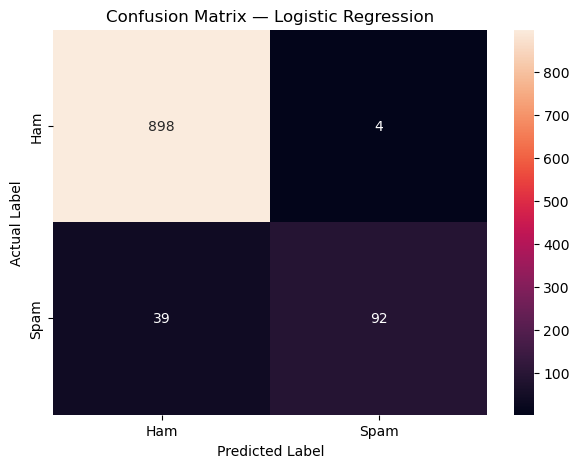

In [117]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [118]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 898
False Positives: 4
False Negatives: 39
True Positives  : 92


In [119]:
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")

Specificity: 0.9956


In [120]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    spam_probability
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9931


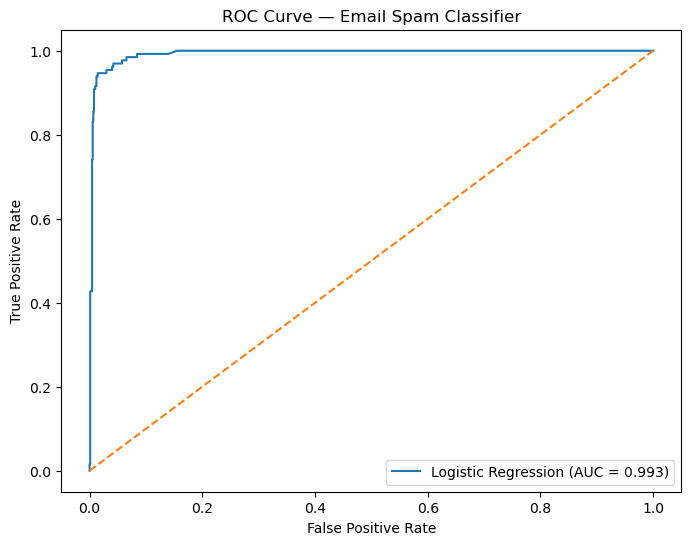

In [121]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    spam_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve — Email Spam Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [122]:
false_positives = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

print("False positives:", len(false_positives))

false_positives[
    [
        "message",
        "actual_label",
        "predicted_label",
        "spam_probability"
    ]
].sort_values(
    "spam_probability",
    ascending=False
).head(20)

False positives: 4


,message,actual_label,predicted_label,spam_probability
292,free nowcan call,ham,spam,0.933554
764,waiting machan call free,ham,spam,0.675430
12,u call,ham,spam,0.671309
511,call senthil hsbc,ham,spam,0.671309


In [123]:
false_negatives = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

print("False negatives:", len(false_negatives))

false_negatives[
    [
        "message",
        "actual_label",
        "predicted_label",
        "spam_probability"
    ]
].sort_values(
    "spam_probability",
    ascending=True
).head(20)

False negatives: 39


,message,actual_label,predicted_label,spam_probability
453,ringtoneking 84484,spam,ham,0.080044
559,simpson movie released july 2007 name band die...,spam,ham,0.096174
651,latest news police station toilet stolen cop n...,spam,ham,0.106491
325,datingi two started sent text talk sport radio...,spam,ham,0.110241
552,hi lucy hubby meetins day fri b alone hotel u ...,spam,ham,0.122521
960,88066 88066 lost 3pound help,spam,ham,0.124180
909,babe u want dont u baby im nasty thing 4 filth...,spam,ham,0.135023
128,want explicit sex 30 sec ring 02073162414 cost...,spam,ham,0.176296
301,missed call alert number called left message 0...,spam,ham,0.200866
583,check choose babe video smsshsexnetun fgkslpop...,spam,ham,0.211093


In [124]:
results.sort_values(
    "spam_probability",
    ascending=False
).head(20)[
    [
        "message",
        "actual_label",
        "predicted_label",
        "spam_probability"
    ]
]

,message,actual_label,predicted_label,spam_probability
854,tone club sub expired 2 resub reply monoc 4 mo...,spam,spam,0.942211
944,message free welcome new improved sex dogging ...,spam,spam,0.938500
292,free nowcan call,ham,spam,0.933554
523,guaranteed £1000 cash £2000 prize claim yr pri...,spam,spam,0.897192
436,discount code rp176781 stop message reply stop...,spam,spam,0.896384
823,guaranteed £1000 cash £2000 prize claim yr pri...,spam,spam,0.882130
634,free unlimited hardcore porn direct 2 mobile t...,spam,spam,0.880250
805,urgent mobile number awarded 2000 prize guaran...,spam,spam,0.877732
102,guaranteed £200 award even £1000 cashto claim ...,spam,spam,0.872180
180,urgent mobile number awarded £2000 prize guara...,spam,spam,0.864435


In [125]:
results.sort_values(
    "spam_probability",
    ascending=True
).head(20)[
    [
        "message",
        "actual_label",
        "predicted_label",
        "spam_probability"
    ]
]

,message,actual_label,predicted_label,spam_probability
227,ok vldo u know got adsense approved,ham,ham,0.010816
613,got ltgt,ham,ham,0.011671
1025,know ltgt ill around 5,ham,ham,0.012191
785,ok ill right later,ham,ham,0.012580
943,ltgt think say syllabus,ham,ham,0.012811
498,im gloucesterroad uup later,ham,ham,0.012938
1032,im lip synced shangela,ham,ham,0.013123
381,hello yeah ive got bath need hair ill come im ...,ham,ham,0.013229
562,ok thk got u wan 2 come wat,ham,ham,0.014022
696,u need presnts always bcz u cant mi love jeevi...,ham,ham,0.014060


In [126]:
feature_names = tfidf.get_feature_names_out()

coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

In [127]:
top_spam_features = feature_importance.sort_values(
    "coefficient",
    ascending=False
).head(30)

top_spam_features

,feature,coefficient
4401,txt,4.090393
1913,free,3.986982
2770,mobile,3.414688
4130,text,3.179884
1109,claim,3.156581
900,call,3.155868
3393,reply,3.144628
3933,stop,3.098044
3199,prize,2.780396
3628,service,2.740042


In [128]:
top_spam_features = feature_importance.sort_values(
    "coefficient",
    ascending=False
).head(30)

top_spam_features

,feature,coefficient
4401,txt,4.090393
1913,free,3.986982
2770,mobile,3.414688
4130,text,3.179884
1109,claim,3.156581
900,call,3.155868
3393,reply,3.144628
3933,stop,3.098044
3199,prize,2.780396
3628,service,2.740042


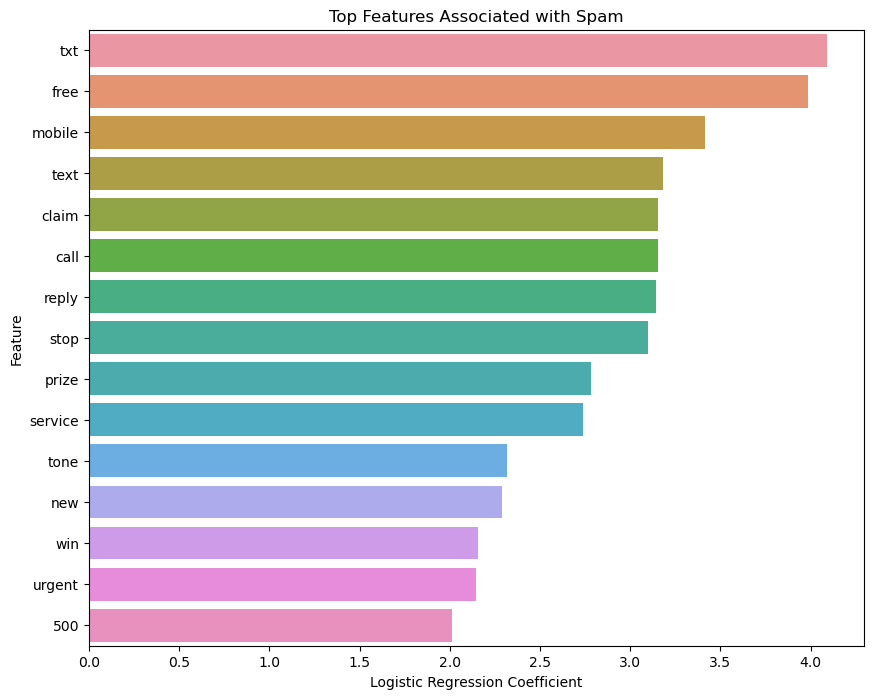

In [129]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_spam_features.head(15),
    x="coefficient",
    y="feature"
)

plt.title("Top Features Associated with Spam")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [131]:
MODEL_PATH = BASE_DIR / r"C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\models" / "spam_classifier.pkl"

joblib.dump(
    model,
    MODEL_PATH
)

print("Model saved successfully:")
print(MODEL_PATH)

Model saved successfully:
C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\models\spam_classifier.pkl


In [132]:
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Specificity",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        specificity,
        roc_auc
    ]
})

metrics["Score"] = metrics["Score"].round(4)

metrics

,Metric,Score
0,Accuracy,0.9584
1,Precision,0.9583
2,Recall,0.7023
3,F1 Score,0.8106
4,Specificity,0.9956
5,ROC-AUC,0.9931


In [134]:
print("=" * 60)
print("EMAIL SPAM CLASSIFIER — MODEL SUMMARY")
print("=" * 60)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"TF-IDF features  : {X_train_tfidf.shape[1]}")

print("\nModel:")
print("Logistic Regression")

print("\nPerformance:")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nModel saved to:")
print(MODEL_PATH)

print("\nProject completed successfully.")

EMAIL SPAM CLASSIFIER — MODEL SUMMARY
Training samples : 4131
Testing samples  : 1033
TF-IDF features  : 5000

Model:
Logistic Regression

Performance:
Accuracy    : 0.9584
Precision   : 0.9583
Recall      : 0.7023
F1 Score    : 0.8106
Specificity : 0.9956
ROC-AUC     : 0.9931

Confusion Matrix:
[[898   4]
 [ 39  92]]

Model saved to:
C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier\models\spam_classifier.pkl

Project completed successfully.


In [135]:
import pandas as pd
import numpy as np
import joblib
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [136]:
import os

BASE_DIR = r"C:\Users\Hp\OneDrive\Desktop\Email-Spam-Classifier"

MODEL_PATH = os.path.join(BASE_DIR, "models", "spam_classifier.pkl")
VECTORIZER_PATH = os.path.join(BASE_DIR, "models", "tfidf_vectorizer.pkl")

model = joblib.load(MODEL_PATH)
tfidf = joblib.load(VECTORIZER_PATH)

print("Model loaded successfully.")
print("TF-IDF vectorizer loaded successfully.")

Model loaded successfully.
TF-IDF vectorizer loaded successfully.


In [137]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

print("NLP preprocessing tools loaded.")

NLP preprocessing tools loaded.


In [138]:
def clean_text(text):
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [139]:
def predict_spam(message):
    
    # Clean input
    cleaned_message = clean_text(message)
    
    # Convert text into TF-IDF
    message_tfidf = tfidf.transform([cleaned_message])
    
    # Prediction
    prediction = model.predict(message_tfidf)[0]
    
    # Probability
    probability = model.predict_proba(message_tfidf)[0]
    
    ham_probability = probability[0]
    spam_probability = probability[1]
    
    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"
    
    return {
        "message": message,
        "cleaned_message": cleaned_message,
        "prediction": result,
        "ham_probability": ham_probability,
        "spam_probability": spam_probability
    }

In [140]:
message = "Hey, are we meeting for lunch today?"

result = predict_spam(message)

print("Message:")
print(result["message"])

print("\nCleaned Message:")
print(result["cleaned_message"])

print("\nPrediction:")
print(result["prediction"])

print("\nHam Probability:")
print(f"{result['ham_probability']:.2%}")

print("\nSpam Probability:")
print(f"{result['spam_probability']:.2%}")

Message:
Hey, are we meeting for lunch today?

Cleaned Message:
hey meeting lunch today

Prediction:
HAM

Ham Probability:
96.42%

Spam Probability:
3.58%


In [141]:
message = "Congratulations! You have won a $1000 prize. Click here to claim your reward now!"

result = predict_spam(message)

print("Message:")
print(result["message"])

print("\nPrediction:")
print(result["prediction"])

print("\nHam Probability:")
print(f"{result['ham_probability']:.2%}")

print("\nSpam Probability:")
print(f"{result['spam_probability']:.2%}")

Message:
Congratulations! You have won a $1000 prize. Click here to claim your reward now!

Prediction:
SPAM

Ham Probability:
31.94%

Spam Probability:
68.06%


In [142]:
test_messages = [
    "Hey, what time are you coming home?",
    "Congratulations! You won a free vacation. Call now!",
    "Can you send me the project report?",
    "URGENT! You have won a cash prize. Click the link now!",
    "Your appointment is confirmed for tomorrow at 10 AM."
]

results = []

for message in test_messages:
    result = predict_spam(message)
    
    results.append({
        "Message": message,
        "Prediction": result["prediction"],
        "Ham Probability": result["ham_probability"],
        "Spam Probability": result["spam_probability"]
    })

prediction_df = pd.DataFrame(results)

prediction_df

,Message,Prediction,Ham Probability,Spam Probability
0,"Hey, what time are you coming home?",HAM,0.972980,0.027020
1,Congratulations! You won a free vacation. Call...,SPAM,0.226714,0.773286
2,Can you send me the project report?,HAM,0.903230,0.096770
3,URGENT! You have won a cash prize. Click the l...,SPAM,0.292452,0.707548
4,Your appointment is confirmed for tomorrow at ...,HAM,0.910487,0.089513


In [143]:
prediction_df["Ham Probability"] = (
    prediction_df["Ham Probability"] * 100
).round(2)

prediction_df["Spam Probability"] = (
    prediction_df["Spam Probability"] * 100
).round(2)

prediction_df

,Message,Prediction,Ham Probability,Spam Probability
0,"Hey, what time are you coming home?",HAM,97.30,2.70
1,Congratulations! You won a free vacation. Call...,SPAM,22.67,77.33
2,Can you send me the project report?,HAM,90.32,9.68
3,URGENT! You have won a cash prize. Click the l...,SPAM,29.25,70.75
4,Your appointment is confirmed for tomorrow at ...,HAM,91.05,8.95


In [145]:
user_message = input("Enter your email/SMS message: ")

result = predict_spam(user_message)

print("\n" + "=" * 60)
print("EMAIL / SMS SPAM CLASSIFIER")
print("=" * 60)

print("\nMessage:")
print(result["message"])

print("\nPrediction:")
print(result["prediction"])

print("\nHam Probability:")
print(f"{result['ham_probability']:.2%}")

print("\nSpam Probability:")
print(f"{result['spam_probability']:.2%}")

print("=" * 60)

Enter your email/SMS message: dear team , find attached file fyr

EMAIL / SMS SPAM CLASSIFIER

Message:
dear team , find attached file fyr

Prediction:
HAM

Ham Probability:
89.31%

Spam Probability:
10.69%


In [146]:
def predict_and_display(message):
    
    result = predict_spam(message)
    
    print("\n" + "=" * 70)
    print("📧 EMAIL SPAM CLASSIFIER")
    print("=" * 70)
    
    print(f"\n📩 Message:\n{result['message']}")
    
    print(f"\n🤖 Prediction: {result['prediction']}")
    
    print(
        f"\n🟢 Ham Probability: "
        f"{result['ham_probability']:.2%}"
    )
    
    print(
        f"🔴 Spam Probability: "
        f"{result['spam_probability']:.2%}"
    )
    
    print("\n" + "=" * 70)
    
    return result

In [147]:
user_message = input("Enter your message: ")

predict_and_display(user_message)

Enter your message: Hii find the attached file

📧 EMAIL SPAM CLASSIFIER

📩 Message:
Hii find the attached file

🤖 Prediction: HAM

🟢 Ham Probability: 88.82%
🔴 Spam Probability: 11.18%



{'message': 'Hii find the attached file',
 'cleaned_message': 'hii find attached file',
 'prediction': 'HAM',
 'ham_probability': 0.8882147294652897,
 'spam_probability': 0.11178527053471034}